## Лабораторная работа 3 "Реализация AED на основе одного из акустических признаков и одного из классификаторов"

Вариант 2 MFCC + Desision Tree

Импорты

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [53]:
df = pd.read_csv("train.csv")

print(df.head())

                      fname            label
0  8bcbcc394ba64fe85ed4.wav  Finger_snapping
1  00d77b917e241afa06f1.wav           Squeak
2  17bb93b73b8e79234cb3.wav   Electric_piano
3  7d5c7a40a936136da55e.wav        Harmonica
4  17e0ee7565a33d6c2326.wav       Snare_drum


In [54]:
df['label'].value_counts()

label
Fart                     195
Flute                    194
Double_bass              191
Trumpet                  188
Acoustic_guitar          187
Cello                    186
Shatter                  184
Applause                 183
Bass_drum                181
Fireworks                180
Hi-hat                   180
Gong                     180
Saxophone                179
Clarinet                 176
Laughter                 174
Snare_drum               173
Squeak                   171
Violin_or_fiddle         167
Cough                    163
Tearing                  162
Oboe                     162
Writing                  161
Knock                    153
Bark                     147
Tambourine               135
Cowbell                  117
Burping_or_eructation    113
Meow                      99
Drawer_open_or_close      94
Microwave_oven            90
Gunshot_or_gunfire        88
Harmonica                 85
Keys_jangling             83
Electric_piano            81
Finger_s

In [55]:
df['label'].unique()

<StringArray>
[      'Finger_snapping',                'Squeak',        'Electric_piano',
             'Harmonica',            'Snare_drum',               'Trumpet',
     'Computer_keyboard',              'Clarinet',              'Laughter',
               'Tearing',              'Applause',               'Shatter',
                 'Knock',             'Bass_drum',               'Cowbell',
          'Glockenspiel',           'Double_bass',             'Fireworks',
               'Writing',                 'Cough',             'Saxophone',
                  'Bark',         'Keys_jangling',                 'Flute',
                  'Meow',                  'Oboe',                 'Cello',
                'Hi-hat',                  'Fart', 'Burping_or_eructation',
  'Drawer_open_or_close',        'Microwave_oven',       'Acoustic_guitar',
            'Tambourine',                  'Gong',      'Violin_or_fiddle',
    'Gunshot_or_gunfire',             'Telephone',                   'Bus'

In [56]:
audio_dir = "C:\\Users\\nikita\\lb\\DSP2026\\lb1\\audio_train\\train"

Функция для извлечения признаков MFCC из аудиосигнала с поддержкой окон и статистик: она загружает аудиофайл, при включенном разбиении на окна делит сигнал на перекрывающиеся сегменты, применяет при необходимости оконную функцию (hamming, hann, blackman), вычисляет MFCC для каждого окна, усредняет по коэффициентам, а затем вычисляет выбранные статистики (mean, std, min, max, median) по всем окнам и объединяет их в итоговый вектор признаков

In [57]:
def extract_features(file_path, 
                     n_mfcc=13, 
                     use_window=True, 
                     window_duration=0.25, 
                     overlap=0.5, 
                     stats=['mean','std'], 
                     window_func='none'):
    y, sr = librosa.load(file_path, sr=None)
    
    if not use_window:
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        features = np.mean(mfccs, axis=1)
        return features
    
    window_size = int(window_duration * sr)
    hop_length = int(window_size * (1 - overlap))
    
    windows = []
    for i in range(0, len(y)-window_size+1, hop_length):
        w = y[i:i+window_size]
        if window_func == 'hamming':
            w = w * np.hamming(window_size)
        elif window_func == 'hann':
            w = w * np.hanning(window_size)
        elif window_func == 'blackman':
            w = w * np.blackman(window_size)
        windows.append(w)
    
    # MFCC по окнам
    window_features = []
    for w in windows:
        mfccs = librosa.feature.mfcc(y=w, sr=sr, n_mfcc=n_mfcc)
        window_features.append(np.mean(mfccs, axis=1))
    
    window_features = np.array(window_features)
    
    # Статистики
    stats_functions = {
        'mean': np.mean,
        'std': np.std,
        'min': np.min,
        'max': np.max,
        'median': np.median
    }
    feat_list = [stats_functions[s](window_features, axis=0) for s in stats if s in stats_functions]
    features = np.concatenate(feat_list)
    return features

In [58]:
def build_dataset(df, audio_dir, n_mfcc=13, use_window=False, window_duration=0.25,
                  overlap=0.5, stats=['mean','std'], window_func='none'):
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(audio_dir, row['fname'])
        features = extract_features(path,
                                    n_mfcc=n_mfcc,
                                    use_window=use_window,
                                    window_duration=window_duration,
                                    overlap=overlap,
                                    stats=stats,
                                    window_func=window_func)
        X.append(features)
        y.append(row['label'])
    return np.array(X), np.array(y)

In [59]:
def split_data(X, y, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    # Кодируем метки
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_encoded, test_size=(1-train_ratio), stratify=y_encoded, random_state=random_state
    )
    
    val_size = val_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1-val_size), stratify=y_temp, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test, le

Функция для обучения Decision Tree на тренировочных данных и оценивает его работу на трёх наборах: train, validation и test

In [60]:
def run_decision_tree(X_train, X_val, X_test, y_train, y_val, y_test, model_name="Decision Tree"):
    # Масштабирование
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    clf = DecisionTreeClassifier()
    clf.fit(X_train_s, y_train)
    
    # Метрики
    def print_metrics(name, X, y):
        y_pred = clf.predict(X)
        acc = accuracy_score(y, y_pred)
        f1_m = f1_score(y, y_pred, average='macro')
        print(f"{name} -> Accuracy: {acc:.3f}, F1 macro: {f1_m:.3f}")
        return y_pred, acc, f1_m
    
    y_val_pred, acc_val, f1_val = print_metrics("Validation", X_val_s, y_val)
    y_test_pred, acc_test, f1_test = print_metrics("Test", X_test_s, y_test)
    y_train_pred, acc_train, f1_train = print_metrics("Train", X_train_s, y_train)
    
    # Матрица ошибок по тесту
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Confusion Matrix ({model_name} - Test)")
    plt.show()
    
    return {
        'model_name': model_name,
        'train': {'acc': acc_train, 'f1': f1_train},
        'val': {'acc': acc_val, 'f1': f1_val},
        'test': {'acc': acc_test, 'f1': f1_test}
    }

Обучаем Decision Tree на MFCC (13 коэффициентов) без оконных функций

Validation -> Accuracy: 0.335, F1 macro: 0.310
Test -> Accuracy: 0.321, F1 macro: 0.300
Train -> Accuracy: 1.000, F1 macro: 1.000


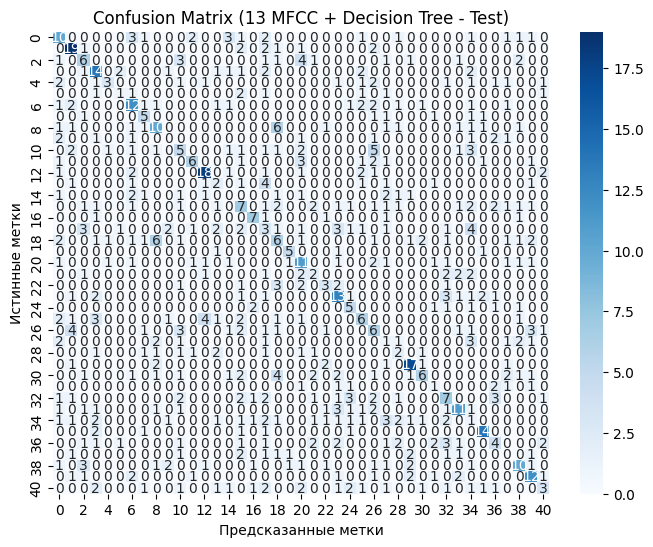

In [61]:

X, y = build_dataset(df, audio_dir, n_mfcc=13, use_window=True, window_duration=0.25, overlap=0.5, stats=['mean','std','min','max'])

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results = run_decision_tree(X_train, X_val, X_test, y_train, y_val, y_test, model_name="13 MFCC + Decision Tree")

Модель сильно переобучена: на тренировке точность 100%, а на валидации и тесте — около 30%. MFCC 13 с текущими статистиками не дают достаточной информации, нужно либо регуляризовать дерево, либо подбирать гиперпараметры и использовать оконные функции для улучшения обобщающей способности.

Обучаем Decision Tree на двух статистиках, без окон с mfcc 15

Validation -> Accuracy: 0.300, F1 macro: 0.285
Test -> Accuracy: 0.314, F1 macro: 0.298
Train -> Accuracy: 1.000, F1 macro: 1.000


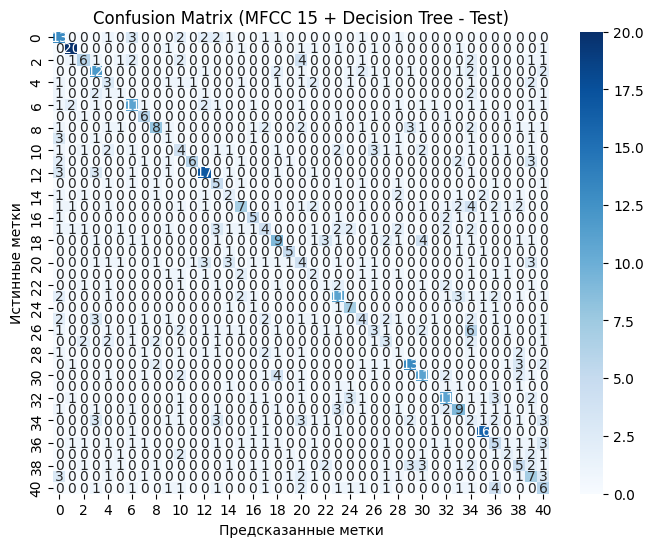

In [63]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,
    use_window=True,
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std']
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_1 = run_decision_tree(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + Decision Tree"
)

Результаты показывают сильное переобучение: на тренировке точность и F1 = 1.0, а на валидации и тесте показатели падают до 30%. MFCC 15 с базовыми статистиками (mean и std) показало результат чуть лучше чем mfcc = 15.

Обучаем Decision Tree на MFCC (13 коэффициентов) без оконных функций добавляем статистику 'median'

Validation -> Accuracy: 0.298, F1 macro: 0.282
Test -> Accuracy: 0.313, F1 macro: 0.305
Train -> Accuracy: 1.000, F1 macro: 1.000


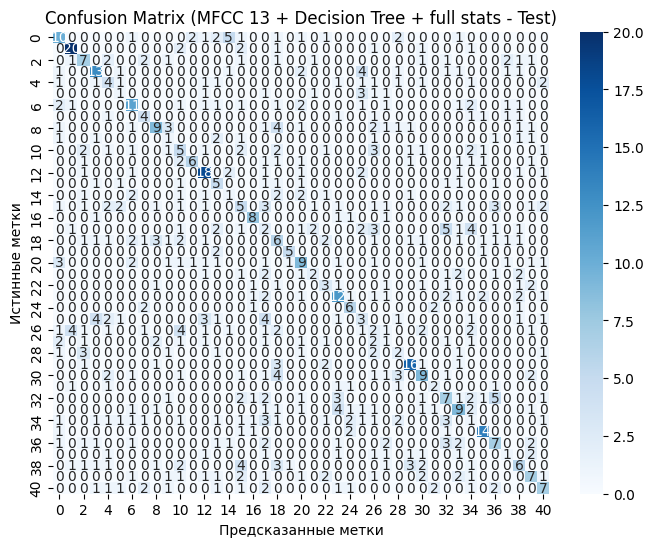

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=13,
    use_window=True,
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std','min','max','median']
)
X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_2 = run_decision_tree(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 13 + Decision Tree + full stats"
)

При mfcc=13 и всеми статистиками модель так же не выдала хороших результатов, стало даже немного хуже, модель так же переобучилась на train

Обучаем на 4 статистиках mfcc = 15 (так как прежде выдало лучше результат) и применяем окно Хэмминга 

Validation -> Accuracy: 0.296, F1 macro: 0.270
Test -> Accuracy: 0.313, F1 macro: 0.290
Train -> Accuracy: 1.000, F1 macro: 1.000


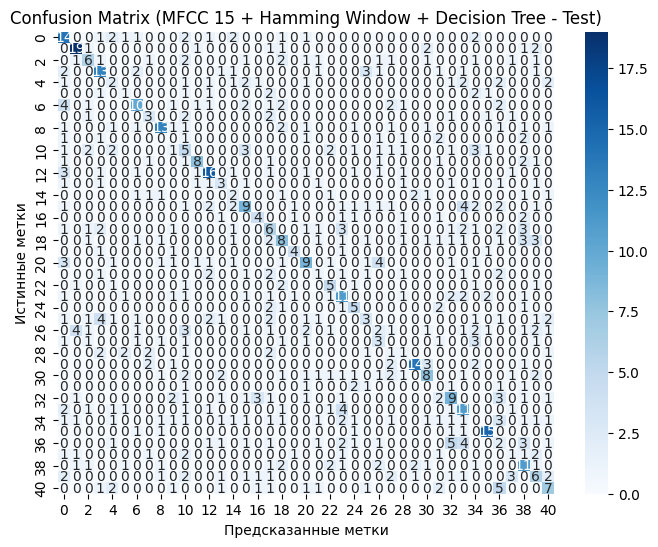

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,
    use_window=True,
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std','min','max'],
    window_func='hamming'  
)


X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)
results_3 = run_decision_tree(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + Hamming Window + Decision Tree"
)

Добавление окна Хэмминга и расширенных статистик (mean, std, min, max) на MFCC 15 не привело к заметному улучшению точности: на тренировке дерево по-прежнему полностью запомнило данные (accuracy и F1 = 1.0), а на валидации и тесте показатели остаются низкими (27–29% F1). То есть окно Хэмминга не сильно повлияло на обобщающую способность модели

Обучаем на 4 статистиках mfcc = 15 (так как прежде выдало лучше результат) и применяем окно Ханна

Validation -> Accuracy: 0.305, F1 macro: 0.271
Test -> Accuracy: 0.356, F1 macro: 0.340
Train -> Accuracy: 1.000, F1 macro: 1.000


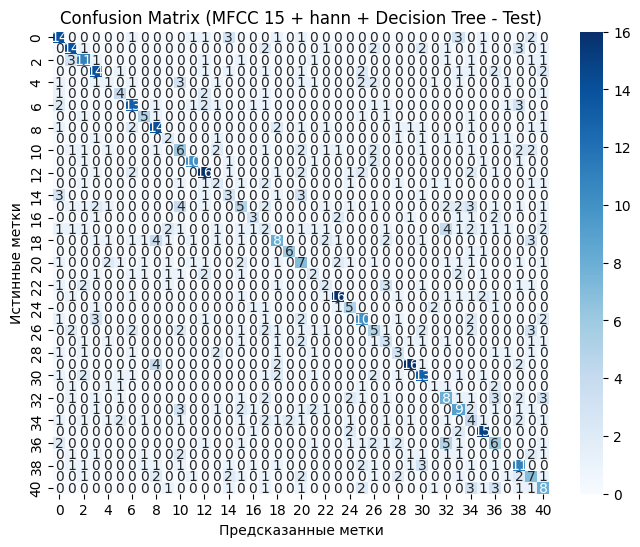

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,
    use_window=True,
    window_duration=0.15,
    overlap=0.4,
    stats=['mean','std','min','max'],
    window_func='hann'
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_4 = run_decision_tree(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + hann + Decision Tree"
)

Применение окна Ханна не сильно улучшило результат, модель так же переобучилась, однако на тесте F1 выдало пока что лучший результат в сравнении с остальными 0.340

Обучаем на 4 статистиках mfcc = 15 (так как прежде выдало лучше результат) и применяем окнную функцию Блэкмэна

Validation -> Accuracy: 0.311, F1 macro: 0.281
Test -> Accuracy: 0.343, F1 macro: 0.327
Train -> Accuracy: 1.000, F1 macro: 1.000


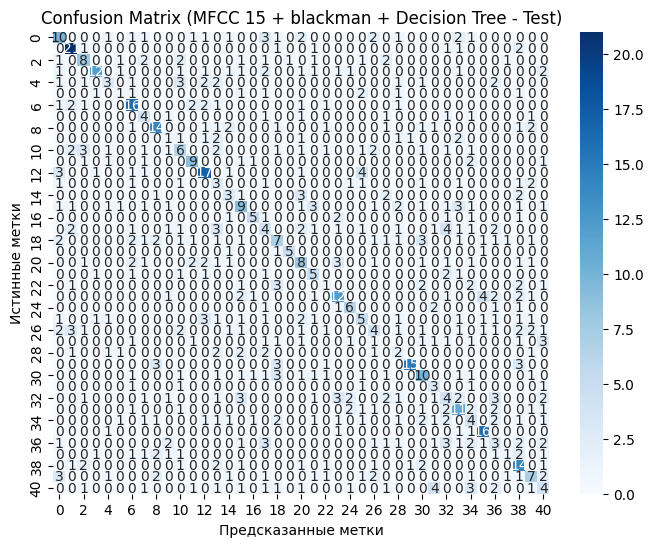

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,
    use_window=True,
    window_duration=0.15,
    overlap=0.4,
    stats=['mean','std','min','max'],
    window_func='blackman'
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_4_1 = run_decision_tree(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + blackman + Decision Tree"
)

Результаты показали очень высокую точность на обучающей выборке (Accuracy = 1.0, F1 = 1.0), что указывает на переобучение модели. При этом на валидационной и тестовой выборках качество значительно ниже (F1 ≈ 0.28–0.33). Использование окна Блэкмана немного улучшило результаты на тестовой выборке по сравнению с некоторыми предыдущими экспериментами, однако проблема переобучения модели остаётся

Пробуем с GridSearchCV

Делаем функцию которая будет рассчитывать гиперпараметры для decision tree с помощью GridSearchCV

In [ ]:
def run_decision_tree_gridsearch(X_train, X_val, X_test, y_train, y_val, y_test, model_name="Decision Tree GridSearch"):

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    
    param_grid = {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    clf = DecisionTreeClassifier(random_state=42)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid_search = GridSearchCV(clf, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)
    grid_search.fit(X_train_s, y_train)
    
    best_clf = grid_search.best_estimator_
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    
    def print_metrics(name, X, y):
        y_pred = best_clf.predict(X)
        acc = accuracy_score(y, y_pred)
        f1_m = f1_score(y, y_pred, average='macro')
        print(f"{name} -> Accuracy: {acc:.3f}, F1 macro: {f1_m:.3f}")
        return y_pred, acc, f1_m
    
    y_train_pred, acc_train, f1_train = print_metrics("Train", X_train_s, y_train)
    y_val_pred, acc_val, f1_val = print_metrics("Validation", X_val_s, y_val)
    y_test_pred, acc_test, f1_test = print_metrics("Test", X_test_s, y_test)
    
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Confusion Matrix ({model_name} - Test)")
    plt.show()
    
    return {
        'model_name': model_name,
        'best_params': grid_search.best_params_,
        'train': {'acc': acc_train, 'f1': f1_train},
        'val': {'acc': acc_val, 'f1': f1_val},
        'test': {'acc': acc_test, 'f1': f1_test}
    }

Обучаем MFCC 15 + short window + GridSearch

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Train -> Accuracy: 0.850, F1 macro: 0.838
Validation -> Accuracy: 0.308, F1 macro: 0.288
Test -> Accuracy: 0.335, F1 macro: 0.310


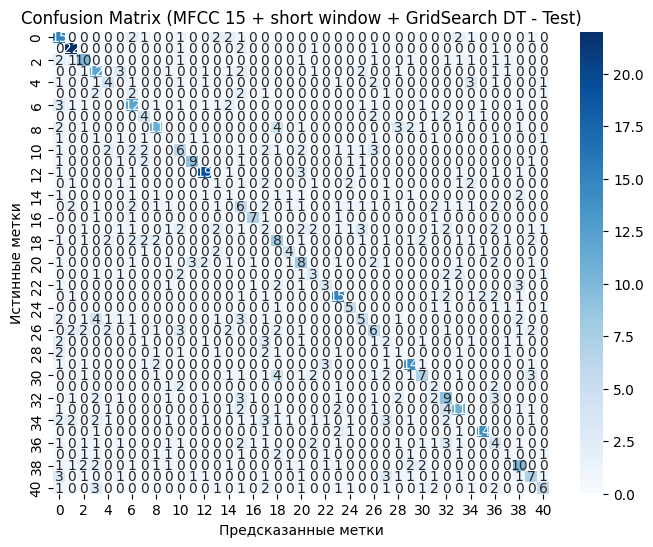

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,       
    use_window=True,    
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std','min','max']
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_5 = run_decision_tree_gridsearch(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + short window + GridSearch DT"
)

Применение GridSearch к дереву решений с MFCC 15 и расширенными статистиками позволило подобрать оптимальные гиперпараметры (max_depth=None, min_samples_split=5, min_samples_leaf=1) и снизить переобучение на тренировке (accuracy и F1 упали до 0.85/0.838). Однако на валидации и тесте показатели остались низкими (~28–31% F1), что говорит о слабой обобщающей способности модели на этом наборе признаков. GridSearch помог немного контролировать переобучение, но не улучшил качество предсказаний на новых данных.

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Train -> Accuracy: 1.000, F1 macro: 1.000
Validation -> Accuracy: 0.292, F1 macro: 0.278
Test -> Accuracy: 0.318, F1 macro: 0.305


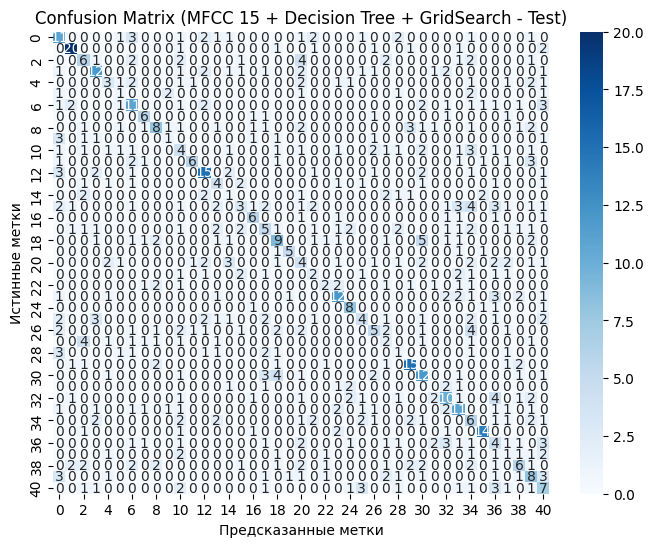

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,
    use_window=True,
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std']
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_grid = run_decision_tree_gridsearch(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + Decision Tree + GridSearch"
)

При сокращении статистик и применении GeidSearch качество сильно снижаниется

MFCC 15 + Hamming + GridSearch DT

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Train -> Accuracy: 0.860, F1 macro: 0.848
Validation -> Accuracy: 0.296, F1 macro: 0.270
Test -> Accuracy: 0.320, F1 macro: 0.292


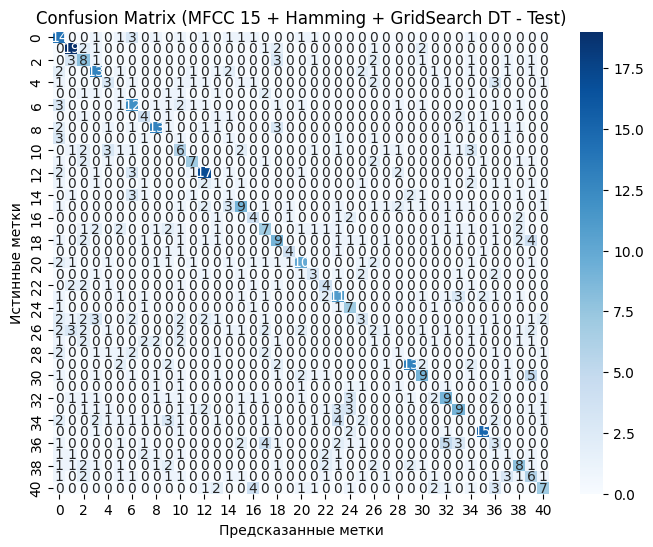

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,       
    use_window=True,    
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std','min','max'],
    window_func='hamming'
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_5_1 = run_decision_tree_gridsearch(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + Hamming + GridSearch DT"
)

MFCC 15 + hann + GridSearch DT

Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Train -> Accuracy: 0.784, F1 macro: 0.765
Validation -> Accuracy: 0.312, F1 macro: 0.294
Test -> Accuracy: 0.328, F1 macro: 0.297


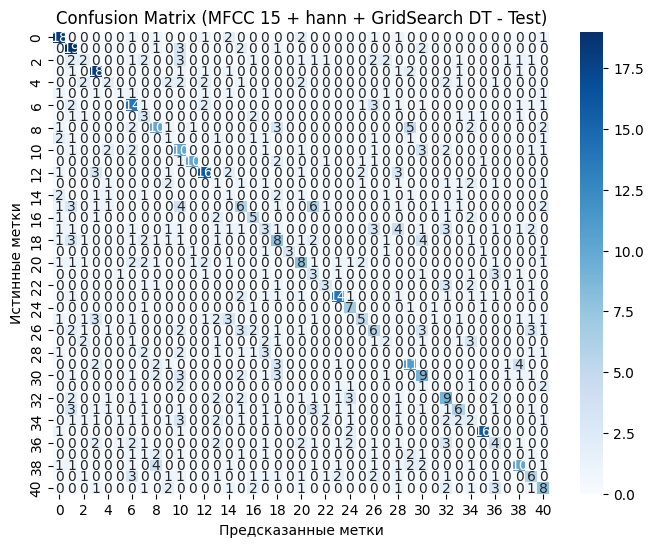

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,       
    use_window=True,    
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std','min','max'],
    window_func='hann'
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_7 = run_decision_tree_gridsearch(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + hann + GridSearch DT"
)

В данной комбинации мы получили наименьшее переобучение, на обучаеющей выборке модель выдала  Accuracy: 0.784, F1 macro: 0.765, что можно считать лучшим результатам в сравнении с другими, однако на тестовой выборке модель так же выдала плохие результаты F1 macro даже хуже чем в моделях без применения GridSearch

MFCC 15 + blackman + GridSearch DT

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Train -> Accuracy: 1.000, F1 macro: 1.000
Validation -> Accuracy: 0.316, F1 macro: 0.293
Test -> Accuracy: 0.322, F1 macro: 0.306


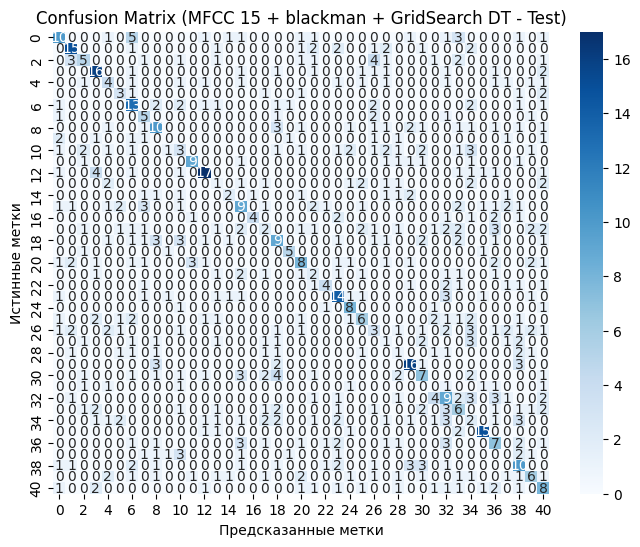

In [ ]:
X, y = build_dataset(
    df,
    audio_dir,
    n_mfcc=15,       
    use_window=True,    
    window_duration=0.25,
    overlap=0.5,
    stats=['mean','std','min','max'],
    window_func='blackman'
)

X_train, X_val, X_test, y_train, y_val, y_test, le = split_data(X, y)

results_8 = run_decision_tree_gridsearch(
    X_train, X_val, X_test, y_train, y_val, y_test,
    model_name="MFCC 15 + blackman + GridSearch DT"
)

Модель так же переобучилась и выдала низкие результаты по Acc и F1 на тесте

In [ ]:
all_results = [
    results,
    results_1,
    results_2,
    results_3,
    results_4,
    results_4_1,
    results_5,
    results_grid,
    results_7,
    results_8,
    results_5_1,
]

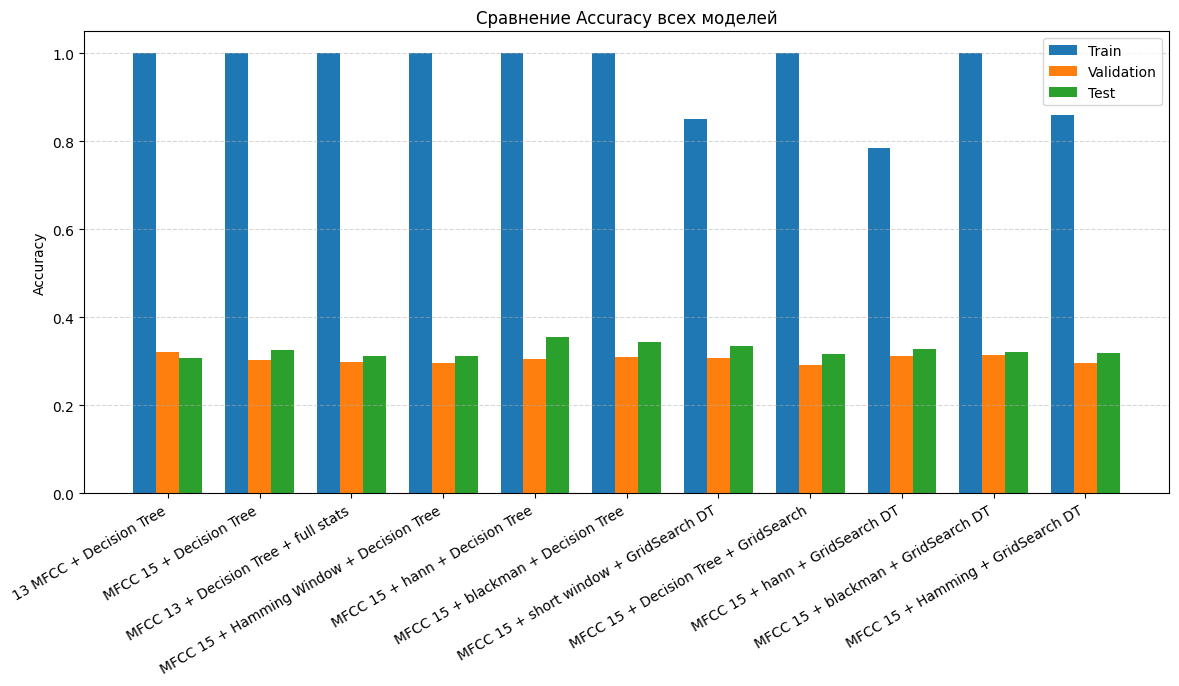

In [ ]:
models = [r['model_name'] for r in all_results]

acc_train = [r['train']['acc'] for r in all_results]
acc_val = [r['val']['acc'] for r in all_results]
acc_test = [r['test']['acc'] for r in all_results]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x - width, acc_train, width, label="Train")
plt.bar(x, acc_val, width, label="Validation")
plt.bar(x + width, acc_test, width, label="Test")

plt.xticks(x, models, rotation=30, ha='right')
plt.ylabel("Accuracy")
plt.title("Сравнение Accuracy всех моделей")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Из графика видно, что модель сильно переобучается на обучающей выборке, особенно стандартный Desision Tree без гиперпараметров,  GridSearch немного уменьшает переобучение, однако по низким результатам на тесте понятно что модель имеет низкую обобщающую способность. Это так же связано с тем, что Decision Tree плохо работает с высокоразмерными и пересекающимися признаковыми пространствами, что характерно для аудио-данных. В результате дерево решений не всегда может корректно разделить классы, имеющие схожие акустические характеристики.

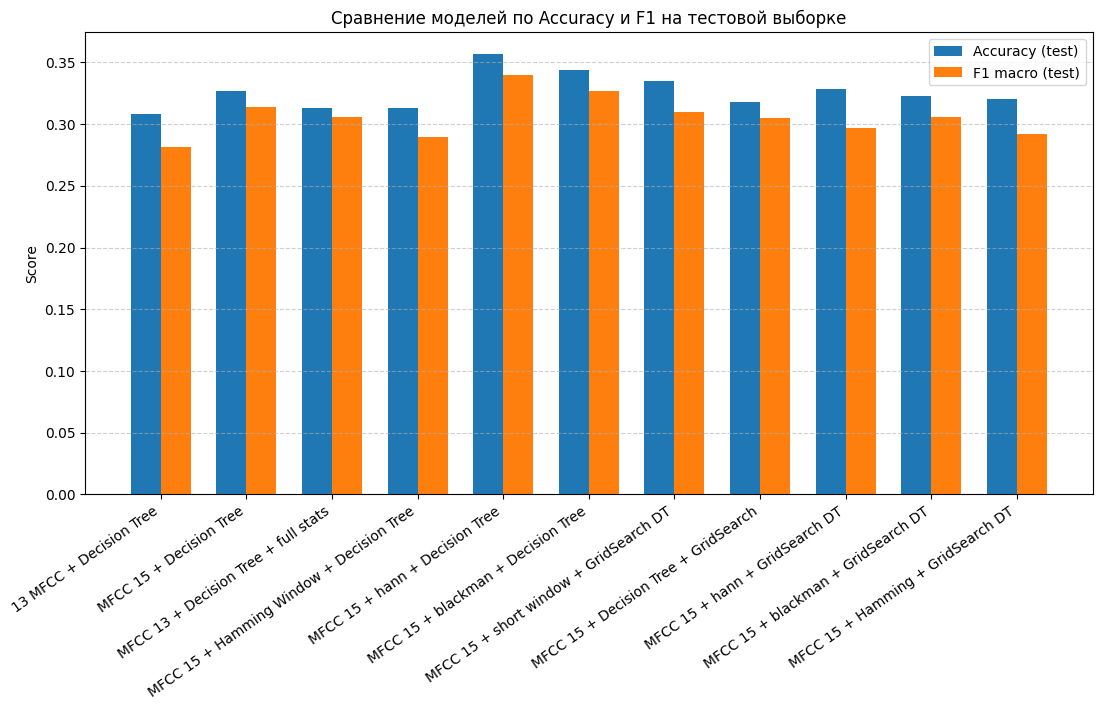

In [ ]:
models = [r['model_name'] for r in all_results]

acc_test = [r['test']['acc'] for r in all_results]
f1_test = [r['test']['f1'] for r in all_results]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(13,6))

plt.bar(x - width/2, acc_test, width, label='Accuracy (test)')
plt.bar(x + width/2, f1_test, width, label='F1 macro (test)')

plt.xticks(x, models, rotation=35, ha='right')
plt.ylabel("Score")
plt.title("Сравнение моделей по Accuracy и F1 на тестовой выборке")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

### **Выводы**

В ходе лабораторной работы была исследована задача классификации аудиосигналов с использованием MFCC-признаков и алгоритма Decision Tree. Были проведены несколько экспериментов с различными параметрами извлечения признаков: изменялось количество MFCC-коэффициентов, набор статистик (mean, std, min, max, median), а также применялись различные оконные функции (Hamming, Hann, Blackman). Кроме того, была проведена настройка гиперпараметров дерева решений с помощью GridSearchCV.

Результаты экспериментов показали, что модель демонстрирует очень высокие метрики на обучающей выборке, однако на валидационной и тестовой выборках качество значительно ниже. Это свидетельствует о переобучении модели Decision Tree на обучающих данных. Изменение параметров MFCC и набора статистик оказывает лишь небольшое влияние на итоговое качество. Применение оконных функций также не привело к существенному улучшению результатов, хотя в отдельных экспериментах наблюдалось незначительное повышение метрик на тестовой выборке, как например лучший результат среди остальных метрик Accuracy и F1 при конфигурации MFCC 15 + hann + Decision Tree с 4 статистиками MFCC, Accuracy: **0.356, F1 macro: 0.340**.

Использование GridSearchCV позволило подобрать более оптимальные параметры дерева решений и немного снизить степень переобучения, однако общее качество классификации осталось примерно на том же уровне (Acc, F1 ~ 27-31). Таким образом, можно сделать вывод, что для данной задачи использование только Decision Tree и MFCC-признаков даёт ограниченные результаты, и для повышения качества классификации могут потребоваться более сложные модели или дополнительные признаки аудиосигнала.

